### Calculating interaction-energy curve

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, scf, qmmm
from pyscf.geomopt.geometric_solver import optimize
import pickle

In [2]:
def move_oh_to_distance(coords, target_distance):

    coords = coords.copy()

    O = 0
    H_oh = 1
    C = 2

    carbon = coords[C]
    oxygen = coords[O]

    # Current direction from C toward O
    direction = oxygen - carbon
    direction /= np.linalg.norm(direction)

    # Preserve the O-H vector
    oh_vector = coords[H_oh] - coords[O]

    # Place O at the desired C-O distance
    new_oxygen = carbon + direction * target_distance

    # Move H together with O
    new_hydrogen = new_oxygen + oh_vector

    coords[O] = new_oxygen
    coords[H_oh] = new_hydrogen

    return coords

def build_molecule(coords):

    atom_string = ""

    for symbol, coord in zip(symbols, coords):

        x, y, z = coord

        atom_string += (
            f"{symbol} "
            f"{x:.10f} "
            f"{y:.10f} "
            f"{z:.10f}\n"
        )

    return gto.M(
        atom=atom_string,
        basis="6-31G",
        charge=-1,
        spin=0,
        unit="Angstrom"
    )
    
def write_constraint(distance):

    with open("constraints.txt", "w") as f:

        f.write("$set\n")
        f.write(
            f"distance 1 3 {distance:.8f}\n"
        )

def make_scf(mol):

    mf = scf.RHF(mol)
    mf = qmmm.mm_charge(
        mf,
        mm_coords,
        mm_charges,
        unit="Angstrom"
    )
    return mf
    
def make_qmmm_scf(mol):

    mf = scf.RHF(mol)
    mf = qmmm.mm_charge(
        mf,
        mm_coords,
        mm_charges,
        unit="Angstrom"
    )

    return mf
    
def optimize_at_distance(mol, distance, maxsteps=15):

    # Create the constraint file
    write_constraint(distance)

    # Build RHF + implicit solvent
    mf = make_scf(mol)

    # Optimize geometry while keeping C-O fixed
    mol_opt = optimize(
        mf,
        constraints="constraints.txt",
        maxsteps=maxsteps
    )

    # Recalculate final energy using the optimized geometry
    mf_final = make_scf(mol_opt)
    energy = mf_final.kernel()

    # Return the optimized geometry and energy
    return mol_opt, energy, mf_final

def write_xyz(mol, filename, distance):

    coords = mol.atom_coords(
        unit="Angstrom"
    )

    with open(filename, "w") as f:

        f.write(f"{mol.natm}\n")

        f.write(
            f"C-O distance = {distance:.8f} Angstrom\n"
        )

        for symbol, coord in zip(symbols, coords):

            x, y, z = coord

            f.write(
                f"{symbol:2s} "
                f"{x:14.8f} "
                f"{y:14.8f} "
                f"{z:14.8f}\n"
            )


In [3]:
initial_xyz = """
O   -5.000   0.000   0.000
H   -5.970   0.000   0.000

C    0.000   0.000   0.000
Cl   1.780   0.000   0.000

H   -0.630   0.630   0.630
H   -0.630  -0.630   0.630
H   -0.630   0.000  -0.890
"""

In [4]:
symbols = [
    "O",
    "H",
    "C",
    "Cl",
    "H",
    "H",
    "H"
]

In [5]:
mm_coords = np.array([
    [0.000, 3.000, 0.000],
    [0.758, 3.504, 0.000],
    [-0.758, 3.504, 0.000]
])

mm_charges = np.array([
    -0.834,
     0.417,
     0.417
])

In [9]:
with open("../7_atoms_3/optimized_mols.pkl", "rb") as f:
    optimized_molecules = pickle.load(f)

In [10]:
# Looking at the energies explicitly saved by the QM code
data = np.loadtxt('../7_atoms_3/energy_abs.txt'); print(np.shape(data))
actual_distances = data[:,0]
energies=data[:,1]
# plt.figure(figsize=(7,5))
# plt.plot(actual_distances,energies_kj,marker="o")
# plt.gca().invert_xaxis()
# plt.xlabel("C-O distance (Å)")
# plt.ylabel("Energy (kJ/mol)")
# plt.title("Relaxed C-O Reaction Coordinate")
# plt.grid(True)
# plt.show()

(5, 2)


In [11]:
mol = gto.M(
    atom=initial_xyz,
    basis="6-31G",
    charge=-1,
    spin=0,
    unit="Angstrom"
)

In [12]:
qmmm_energies = []
qmmm_mfs = []

for i, mol in enumerate(optimized_molecules):

    print("=" * 70)
    print(f"FRAME {i+1}/{len(optimized_molecules)}")

    mf = make_qmmm_scf(mol)
    energy = mf.kernel()

    qmmm_energies.append(energy)
    qmmm_mfs.append(mf)

    print(f"QM/MM energy: {energy:.12f} Hartree")

FRAME 1/5
converged SCF energy = -574.398153930046
QM/MM energy: -574.398153930046 Hartree
FRAME 2/5
converged SCF energy = -574.407510720348
QM/MM energy: -574.407510720348 Hartree
FRAME 3/5
converged SCF energy = -574.442449359596
QM/MM energy: -574.442449359596 Hartree
FRAME 4/5
converged SCF energy = -574.504534132862
QM/MM energy: -574.504534132862 Hartree
FRAME 5/5
converged SCF energy = -574.461352990186
QM/MM energy: -574.461352990186 Hartree


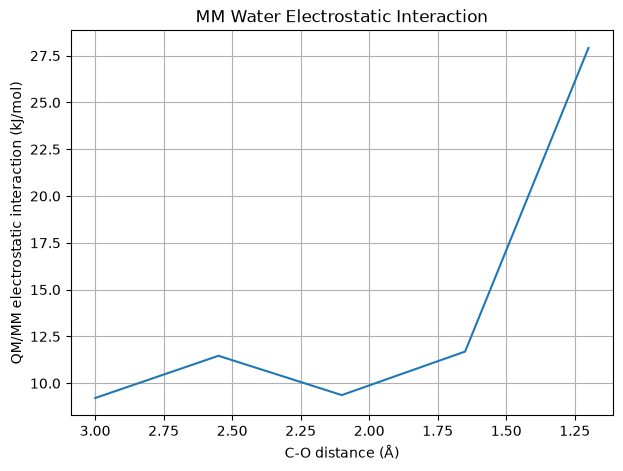

In [13]:
qmmm_energies_Hartree = np.array(qmmm_energies)
gas_energies_Hartree = energies
mm_interaction = (
    (qmmm_energies_Hartree - gas_energies_Hartree)*2626
)

plt.figure(figsize=(7,5))
plt.plot(actual_distances,mm_interaction)
plt.gca().invert_xaxis()
plt.xlabel("C-O distance (Å)")
plt.ylabel("QM/MM electrostatic interaction (kJ/mol)")
plt.title("MM Water Electrostatic Interaction")
plt.grid(True)
plt.show()